In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import Statevector
import time
from qiskit_aer import AerSimulator
import gc

def get_gray_indices(n):
    idxs = np.arange(2**n, dtype=np.int32)
    return np.bitwise_xor(idxs, np.right_shift(idxs, 1))

def permute_probs_to_gray(probs_physical, nx, ny, nz):
    gz_indices = get_gray_indices(nz)
    gy_indices = get_gray_indices(ny)
    gx_indices = get_gray_indices(nx)
    
    probs_gray = np.zeros_like(probs_physical)
    
    temp = np.zeros_like(probs_physical)
    temp[gz_indices, :, :] = probs_physical 
    
    temp2 = np.zeros_like(temp)
    temp2[:, gy_indices, :] = temp          
    
    probs_gray[gx_indices] = temp2.transpose(2, 0, 1) 
    probs_gray = probs_gray.transpose(1, 2, 0) 
    
    out = np.zeros_like(probs_physical)
    # Z axis
    out[gz_indices, :, :] = probs_physical
    # Y axis
    res = np.zeros_like(out)
    res[:, gy_indices, :] = out
    # X axis
    final = np.zeros_like(res)
    final[:, :, gx_indices] = res
    
    return final

def restore_amps_from_gray(amps_gray_flat, nx, ny, nz):
    Nz, Ny, Nx = 2**nz, 2**ny, 2**nx
    amps_gray_3d = amps_gray_flat.reshape((Nz, Ny, Nx))
    
    gz_indices = get_gray_indices(nz)
    gy_indices = get_gray_indices(ny)
    gx_indices = get_gray_indices(nx)
    
    amps_phys = amps_gray_3d[gz_indices, :, :]
    amps_phys = amps_phys[:, gy_indices, :]
    amps_phys = amps_phys[:, :, gx_indices]
    
    return amps_phys.flatten()

def generate_3d_target_distribution(nx, ny, nz, k_cutoff):
    Nx, Ny, Nz = 2**nx, 2**ny, 2**nz
    kx = np.fft.fftfreq(Nx, d=1/Nx)
    ky = np.fft.fftfreq(Ny, d=1/Ny)
    kz = np.fft.fftfreq(Nz, d=1/Nz)
    
    KZ, KY, KX = np.meshgrid(kz, ky, kx, indexing='ij')
    k_sq = KX**2 + KY**2 + KZ**2
    k_abs = np.sqrt(k_sq)
    
    amplitudes = np.zeros_like(k_sq)
    nonzero_mask = k_sq > 0
    
    gamma = 0
    amplitudes[nonzero_mask] = (k_sq[nonzero_mask])**gamma
    
    smooth_mask = np.exp(- (k_abs / k_cutoff)**10)
    amplitudes *= smooth_mask
    
    probs = amplitudes**2
    target_zero_prob = 0.1
    
    tail_sum = np.sum(probs)
    if tail_sum > 0:
        probs = probs * (1.0 - target_zero_prob) / tail_sum
        
    probs[0, 0, 0] = target_zero_prob
    return probs, (KZ, KY, KX)

def solve_ridge_numpy(X, y, weights, alpha=1e-6):
    N, M = X.shape
    X_aug = np.empty((N, M + 1), dtype=X.dtype)
    X_aug[:, :-1] = X
    X_aug[:, -1] = 1.0  # Bias column
    
    sqrt_w = np.sqrt(weights)[:, None]
    X_w = X_aug * sqrt_w
    y_w = y * weights
    
    # A = (X_aug * weights[:, None]).T @ X_aug
    X_T_W = X_aug.T * weights[None, :]
    A = X_T_W @ X_aug
    b = X_T_W @ y
    
    I = np.eye(M + 1)
    I[-1, -1] = 0.0
    A += alpha * I
    
    try:
        coefs = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        coefs = np.linalg.lstsq(A, b, rcond=None)[0]
        
    return coefs[-1], coefs[:-1] # bias, weights

def process_and_fit_all_layers(probs_gray_3d, nx, ny, nz):
    probs_flat = probs_gray_3d.flatten()
    n_total = nx + ny + nz
    
    CUTOFF = 1e-25
    
    params = []
    
    current_probs = probs_flat
    
    for layer_idx in range(n_total):
        n_features = layer_idx
        n_blocks = 2**n_features
        
        remainder = current_probs.shape[0] // (n_blocks * 2)
        
        reshaped = current_probs.reshape(n_blocks, 2, remainder)
        block_probs = reshaped.sum(axis=2) 
        
        p0 = block_probs[:, 0]
        p1 = block_probs[:, 1]
        w = p0 + p1
        
        y_angles = np.zeros(n_blocks)
        valid_mask = w > CUTOFF
        
        if np.any(valid_mask):
            ratio = np.clip(p0[valid_mask] / w[valid_mask], 0, 1)
            y_angles[valid_mask] = 2 * np.arccos(np.sqrt(ratio))
        
        mask = valid_mask
        
        if np.sum(mask) == 0:
            params.append((0.0, []))
            continue
            
        y_train = y_angles[mask]
        w_train = w[mask]
        
        indices = np.arange(n_blocks)[mask]
        
        if n_features == 0:
            X_train = np.zeros((len(y_train), 0))
        else:
            X_train = ((indices[:, None] & (1 << np.arange(n_features)[::-1])) > 0).astype(float)
        
        amp_weights = w_train**0.5
        max_w = np.max(amp_weights)
        if max_w > 0:
            amp_weights = amp_weights / max_w
            
        if n_features == 0:
            bias = y_train[0]
            weights = []
        elif len(y_train) <= 1:
            bias = y_train[0]
            weights = np.zeros(n_features)
        else:
            bias, weights = solve_ridge_numpy(X_train, y_train, amp_weights, alpha=1e-9)
            
        params.append((bias, weights))
        
    return params

def ZZ(qc, control, target, gamma):
    qc.cx(control, target)
    qc.rz(gamma, target)
    qc.cx(control, target)

def build_3d_coupled_circuit(nx, ny, nz, params, seed=None):
    rng = np.random.default_rng(seed)
    n_total = nx + ny + nz
    qr = QuantumRegister(n_total, 'q')
    qc = QuantumCircuit(qr)
    
    z_qubits = [qr[i] for i in range(nx+ny+nz-1, nx+ny-1, -1)]
    y_qubits = [qr[i] for i in range(nx+ny-1, nx-1, -1)]
    x_qubits = [qr[i] for i in range(nx-1, -1, -1)]
    all_ordered_qubits = z_qubits + y_qubits + x_qubits
    
    for layer_idx, (bias, weights) in enumerate(params):
        if layer_idx >= len(all_ordered_qubits): break
        target_qubit = all_ordered_qubits[layer_idx]
        qc.ry(bias, target_qubit)
        for i, weight in enumerate(weights):
            if np.abs(weight) > 1e-3: 
                control_qubit = all_ordered_qubits[i]
                qc.cry(weight, control_qubit, target_qubit)
    
    phi_rand = rng.uniform(0, 2*np.pi, n_total)
    for i in range(n_total):
        qc.rz(phi_rand[i], qr[i])
        
    # gamma_rand = rng.uniform(0, 2*np.pi, n_total-1)
    # for i in range(n_total-1):
    #     qc.cx(qr[i], qr[i+1])
    #     qc.rz(gamma_rand[i], qr[i+1])
    #     qc.cx(qr[i], qr[i+1])

    for i in range(n_total):
        for j in range(i + 1, n_total):
            gamma_ij = rng.uniform(0, 2*np.pi)
            
            qc.cx(qr[i], qr[j])
            qc.rz(gamma_ij, qr[j])
            qc.cx(qr[i], qr[j])
        
    return qc

def get_radial_avg_fast(k_vals, amp_vals, bins=25):
    min_k, max_k = np.min(k_vals), np.max(k_vals)
    if min_k == max_k: return np.array([min_k]), np.array([np.mean(amp_vals**2)])
    
    k_bins = np.logspace(np.log10(min_k), np.log10(max_k), bins + 1)
    
    # Digitize
    inds = np.digitize(k_vals, k_bins)
    
    n_bins = len(k_bins)
    
    sq_amp = amp_vals**2
    bin_sums = np.bincount(inds, weights=sq_amp, minlength=n_bins+1)
    bin_counts = np.bincount(inds, minlength=n_bins+1)
    
    centers = []
    avgs = []
    
    for i in range(1, len(k_bins)):
        if bin_counts[i] > 0:
            low, high = k_bins[i-1], k_bins[i]
            centers.append(np.sqrt(low*high))
            avgs.append(np.sqrt(bin_sums[i] / bin_counts[i]))
            
    return np.array(centers), np.array(avgs)

nx, ny, nz = 10, 10, 10
n_total = nx + ny + nz
k_cutoff = 15

t0 = time.time()
print("1. Generating 3D Target Distribution...")
target_probs_phys, (KZ, KY, KX) = generate_3d_target_distribution(nx, ny, nz, k_cutoff)
t1 = time.time()
print(f"   Done in {t1-t0:.4f}s")

print("   Converting to Gray Code (Vectorized)...")
target_probs_gray = permute_probs_to_gray(target_probs_phys, nx, ny, nz)
t2 = time.time()
print(f"   Done in {t2-t1:.4f}s")

print("2. Fitting (Vectorized Ridge & Data Prep)...")
# 这里同时完成了 get_training_data 和 fit
amp_params = process_and_fit_all_layers(target_probs_gray, nx, ny, nz)
t3 = time.time()
print(f"   Done in {t3-t2:.4f}s")


print("3. Simulation")
t_sim_start = time.time()
qc1 = build_3d_coupled_circuit(nx, ny, nz, amp_params, seed=2025)
qc2 = build_3d_coupled_circuit(nx, ny, nz, amp_params, seed=2026)

simulator = AerSimulator(method='statevector', max_parallel_threads=16)

def simulate_fast(qc, sim):
    qc_sim = qc.copy()
    qc_sim.save_statevector()
    qc_compiled = transpile(qc_sim, sim, optimization_level=3)
    result = sim.run(qc_compiled).result()
    return result.get_statevector().data

sta_vec_1_data = simulate_fast(qc1, simulator)
sta_vec_2_data = simulate_fast(qc2, simulator)

t_sim_end = time.time()
print(f"   Simulation Done in {t_sim_end-t_sim_start:.4f}s")

print("Transpiling...")
t_trans = time.time()
qc_transpiled = transpile(qc1, basis_gates=['u', 'cz'], optimization_level=3)
print(f"Transpile done in {time.time()-t_trans:.4f}s")
print(f"Transpiled circuit depth: {qc_transpiled.depth()}")

import matplotlib.pyplot as plt
import numpy as np

num_qubits = len(amp_params)
weights_matrix = np.zeros((num_qubits, num_qubits))

for target_idx, (bias, weights) in enumerate(amp_params):
    if len(weights) > 0:
        weights_matrix[target_idx, :len(weights)] = weights

np.save(fr'data/3D/weights_matrix.npy', weights_matrix)

# del target_probs_gray, target_probs_phys
# del KX, KY, KZ
del qc_transpiled, qc1, qc2
gc.collect()

k_flat = np.sqrt(KX**2 + KY**2 + KZ**2).flatten()
amp_sim_gray = np.abs(sta_vec_1_data)
amp_sim_phys = restore_amps_from_gray(amp_sim_gray, nx, ny, nz)

mask = k_flat > 0
k_plot = k_flat[mask]
amp_plot = amp_sim_phys[mask]

c_sim, v_sim = get_radial_avg_fast(k_plot, amp_plot)

1. Generating 3D Target Distribution...
   Done in 7.0402s
   Converting to Gray Code (Vectorized)...
   Done in 6.0389s
2. Fitting (Vectorized Ridge & Data Prep)...
   Done in 4.4763s
3. Simulation
   Simulation Done in 30.0890s
Transpiling...
Transpile done in 0.1192s
Transpiled circuit depth: 259


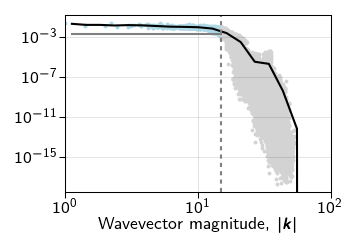

In [ ]:
fig_width = 18/2.54
fig_height = 18/2.54
fig = plt.figure(figsize=(fig_width, fig_height))

ax_width = 4.5/2.54 / fig_width
ax_height = 3/2.54 / fig_height

# 
ax = fig.add_axes([0, 0, ax_width, ax_height])
ax.grid(color='k', linestyle='-', linewidth=0.5, alpha=0.1)

step = 2**(nx-5) if len(k_plot) > 100000 else 1
# step = 1
is_valid_mode = k_plot <= k_cutoff
plt.scatter(k_plot[is_valid_mode][::step], amp_plot[is_valid_mode][::step], 
            marker='.', alpha=1, s=3, color='lightblue', rasterized=True)
plt.scatter(k_plot[~is_valid_mode][::step], amp_plot[~is_valid_mode][::step], 
            marker='.', alpha=1, s=3, color='lightgray', rasterized=True)

plt.plot(c_sim, v_sim, linestyle='-', color='k', linewidth=1, label=r'Averaged amplitude')

if len(c_sim) > 0:
    valid_idxs = np.where(c_sim < k_cutoff)[0]
    if len(valid_idxs) > 0:
        ref_idx = valid_idxs[0]
        ref_k = c_sim[ref_idx]
        ref_v = v_sim[ref_idx]
        k_theory = np.logspace(np.log10(np.min(c_sim)), np.log10(np.max(k_cutoff)), 100)
        v_theory = ref_v * (k_theory / ref_k)**(0)
        plt.plot(k_theory, 0.1*v_theory, linestyle='-', color="gray", linewidth=1, label=r'Theory')
        plt.axvline(x=k_cutoff, color='gray', linestyle='--', dashes=(2, 2), linewidth=1)

plt.xscale('log')
plt.yscale('log')
plt.xlim(1, 1e2) 
plt.xlabel(r'Wavevector magnitude, $|\vec{k}|$', labelpad=0, size=fontsize)
# plt.ylabel(r'Amplitude, $|\psi|$')
# ax.legend(ncol=1, frameon=True, labelspacing=0.2, handlelength=2, handletextpad=0.5, bbox_to_anchor=(0, 0), loc='lower left', fontsize=fontsize)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1.5)
ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1)
ax.tick_params(which='minor', direction='out', top=False, right=False, length=0, width=0.5)

# 
plt.savefig(fr'figure.pdf', transparent=True, orientation='portrait', format='pdf', bbox_inches='tight', dpi=600)

In [2]:
N = 2**nx
kx = np.fft.fftfreq(N)*N
ky = np.fft.fftfreq(N)*N
kz = np.fft.fftfreq(N)*N
KX, KY, KZ = np.meshgrid(kx, ky, kz)
K2 = KX**2 + KY**2 + KZ**2
ik2 = np.round(np.sqrt(K2))

psi1_spec = restore_amps_from_gray(sta_vec_1_data, nx, ny, nz).reshape((2**nz, 2**ny, 2**nx)).T
psi2_spec = restore_amps_from_gray(sta_vec_2_data, nx, ny, nz).reshape((2**nz, 2**ny, 2**nx)).T
del sta_vec_1_data, sta_vec_2_data
gc.collect()

from numpy import pi, sqrt, abs, real, imag

def compute_velocity(psi1, psi2, psi1_spec, psi2_spec, switch):
    rho = np.abs(psi1)**2 + np.abs(psi2)**2

    if (switch == 'SM'):
        dpsi1_x = np.fft.fftn(1j*KX*psi1_spec) / sqrt(N**3)
        dpsi1_y = np.fft.fftn(1j*KY*psi1_spec) / sqrt(N**3)
        dpsi1_z = np.fft.fftn(1j*KZ*psi1_spec) / sqrt(N**3)
        dpsi2_x = np.fft.fftn(1j*KX*psi2_spec) / sqrt(N**3)
        dpsi2_y = np.fft.fftn(1j*KY*psi2_spec) / sqrt(N**3)
        dpsi2_z = np.fft.fftn(1j*KZ*psi2_spec) / sqrt(N**3)
        ux = real(real(psi1)*imag(dpsi1_x) - imag(psi1)*real(dpsi1_x) + real(psi2)*imag(dpsi2_x) - imag(psi2)*real(dpsi2_x)) / rho
        uy = real(real(psi1)*imag(dpsi1_y) - imag(psi1)*real(dpsi1_y) + real(psi2)*imag(dpsi2_y) - imag(psi2)*real(dpsi2_y)) / rho
        uz = real(real(psi1)*imag(dpsi1_z) - imag(psi1)*real(dpsi1_z) + real(psi2)*imag(dpsi2_z) - imag(psi2)*real(dpsi2_z)) / rho
    elif (switch == 'FDM'):
        Jx = np.imag(np.conj(psi1) * (np.roll(psi1, -1, axis=0) - np.roll(psi1, 1, axis=0))) + np.imag(np.conj(psi2) * (np.roll(psi2, -1, axis=0) - np.roll(psi2, 1, axis=0)))
        Jy = np.imag(np.conj(psi1) * (np.roll(psi1, -1, axis=1) - np.roll(psi1, 1, axis=1))) + np.imag(np.conj(psi2) * (np.roll(psi2, -1, axis=1) - np.roll(psi2, 1, axis=1)))
        Jz = np.imag(np.conj(psi1) * (np.roll(psi1, -1, axis=2) - np.roll(psi1, 1, axis=2))) + np.imag(np.conj(psi2) * (np.roll(psi2, -1, axis=2) - np.roll(psi2, 1, axis=2)))
        h = 2*pi / N
        ux = Jx / (2*h) / rho
        uy = Jy / (2*h) / rho
        uz = Jz / (2*h) / rho
        del Jx, Jy, Jz
        gc.collect()
    return rho, ux, uy, uz

def compute_Ek(ux, uy, uz, ik2, N):
    ux_spec = np.fft.fftn(ux) / N**3
    uy_spec = np.fft.fftn(uy) / N**3
    uz_spec = np.fft.fftn(uz) / N**3
    energy_spec = (np.abs(ux_spec)**2 + np.abs(uy_spec)**2 + np.abs(uz_spec)**2) / 2

    nek = N
    Ek = np.zeros(nek)
    k = np.linspace(1, nek, nek)
    for i in range(1, nek+1):
        Ek[i-1] = k[i-1]*np.sum(energy_spec[ik2 == i])
    return k, Ek

psi1 = np.fft.ifftn(psi1_spec)
psi2 = np.fft.ifftn(psi2_spec)

rho, ux, uy, uz = compute_velocity(psi1, psi2, psi1_spec, psi2_spec, 'FDM')
print(np.amin(rho), np.amax(rho), np.mean(rho))

3.93553252996611e-21 1.1307405440295733e-15 1.110223024625156e-16


In [3]:
k, Ek = compute_Ek(ux, uy, uz, ik2, N)

import pandas as pd
pd.DataFrame({'k': k, 'Ek': Ek}).to_csv(fr'data/3D/turb_Ek_nq=30.csv', index=False)

In [4]:
def compute_Es(s, ik2, N):
    s_spec = np.fft.fftn(s) / N**3
    energy_spec = np.abs(s_spec)**2 / 2
    
    nek = N
    Es = np.zeros(nek)
    k = np.linspace(1, nek, nek)
    for i in range(1, nek+1):
        Es[i-1] = k[i-1]*np.sum(energy_spec[ik2 == i])
    return k, Es

s1 = 2*(np.real(psi1)*np.real(psi2) + np.imag(psi1)*np.imag(psi2)) / rho
s2 = 2*(np.real(psi1)*np.imag(psi2) - np.imag(psi1)*np.real(psi2)) / rho
s3 = (np.abs(psi1)**2 - np.abs(psi2)**2) / rho

k, Es1 = compute_Es(s1, ik2, N)
k, Es2 = compute_Es(s2, ik2, N)
k, Es3 = compute_Es(s3, ik2, N)

import pandas as pd
pd.DataFrame({'k': k, 'Es1': Es1, 'Es2': Es2, 'Es3': Es3}).to_csv(fr'data/3D/turb_Es_nq=30.csv', index=False)

In [ ]:
def compute_pdf(variable, Num, bin_num):
    bin_size = (np.amax(variable) - np.amin(variable)) / bin_num
    counts, bin_edges = np.histogram(variable, bins=bin_num, range=(np.amin(variable), np.amax(variable)))
    pdf = counts / (Num * bin_size)
    val = bin_edges[:-1] + bin_size / 2
    return val, pdf

val_rho, pdf_rho = compute_pdf(rho, N**3, 100)

import pandas as pd
pd.DataFrame({'rho': val_rho, 'pdf': pdf_rho}).to_csv(fr'data/3D/turb_PDF_rho_P0=0.999.csv', index=False)

In [3]:
def compute_vorticity(ux, uy, uz, N, switch):
    if (switch == 'SM'):
        ux_spec = np.fft.fftn(ux)
        uy_spec = np.fft.fftn(uy)
        uz_spec = np.fft.fftn(uz)
        vorx = np.real(np.fft.ifftn(1j*(KY*uz_spec - KZ*uy_spec)))
        vory = np.real(np.fft.ifftn(1j*(KZ*ux_spec - KX*uz_spec)))
        vorz = np.real(np.fft.ifftn(1j*(KX*uy_spec - KY*ux_spec)))
    elif (switch == 'FDM'):
        h = 2*pi / N
        vorx = (np.roll(uz, -1, axis=1) - np.roll(uz, 1, axis=1)) - (np.roll(uy, -1, axis=2) - np.roll(uy, 1, axis=2))
        vory = (np.roll(ux, -1, axis=2) - np.roll(ux, 1, axis=2)) - (np.roll(uz, -1, axis=0) - np.roll(uz, 1, axis=0))
        vorz = (np.roll(uy, -1, axis=0) - np.roll(uy, 1, axis=0)) - (np.roll(ux, -1, axis=1) - np.roll(ux, 1, axis=1))
        vorx = vorx / (2*h)
        vory = vory / (2*h)
        vorz = vorz / (2*h)
    return vorx, vory, vorz

vorx, vory, vorz = compute_vorticity(ux, uy, uz, N, 'FDM')
vor = np.sqrt(vorx**2 + vory**2 + vorz**2)
helicity = vorx*ux + vory*uy + vorz*uz

print(np.amin(vor), np.amax(vor), np.mean(vor))
print(np.amin(np.abs(helicity)), np.amax(np.abs(helicity)), np.mean(np.abs(helicity)))

0.00749423449646424 48766.4427702375 74.09822255691687
5.779577350040199e-08 9717559.761803059 410.033442530714


In [ ]:
from matplotlib.colors import LinearSegmentedColormap, hex2color
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def create_smooth_cmap(colors, name='smooth_cmap', N=256):
    rgb_colors = np.array([hex2color(c) for c in colors])
    original_nodes = np.linspace(0, 1, len(rgb_colors))
    f = interp1d(original_nodes, rgb_colors, kind='cubic', axis=0)
    new_nodes = np.linspace(0, 1, N)
    new_colors = f(new_nodes)
    new_colors = np.clip(new_colors, 0, 1)
    return LinearSegmentedColormap.from_list(name, new_colors)

cmap_BuRd = create_smooth_cmap(["#0f5fb5", '#86c5e5', '#ffffff', '#f69d74', "#b80b1f"], 'cmap_BuRd')

import pyvista as pv
from scipy.interpolate import RegularGridInterpolator

L_x, L_y, L_z = 2*np.pi, 2*np.pi, 2*np.pi
N_x, N_y, N_z = N, N, N
spacing = (L_x / (N_x - 1), L_y / (N_y - 1), L_z / (N_z - 1))

grid = pv.ImageData(
    dimensions=(N_x, N_y, N_z),
    spacing=spacing,
    origin=(0, 0, 0)
)

grid.point_data['vor'] = vor.ravel(order='F') 
grid.point_data['helicity'] = helicity.ravel(order='F')

plotter = pv.Plotter(notebook=False, off_screen=True)   # output to file: off_screen=True

contours = grid.contour(isosurfaces=[22], scalars='vor')

if hasattr(contours, 'smooth'):
    contours = contours.smooth(n_iter=100, relaxation_factor=0.1)

bounds = contours.bounds

plotter.add_mesh(contours, scalars='helicity', cmap=cmap_BuRd, clim=[-70, 70], opacity=0.7)
plotter.add_mesh(pv.Box(bounds=bounds), color='white', style='wireframe', line_width=10)
plotter.remove_scalar_bar()

def add_background_plane(plotter, position, normal, size, color='black'):
    plane = pv.Plane(center=position, direction=normal, i_size=size[0], j_size=size[1])
    plotter.add_mesh(plane, color=color, opacity=1)

background_planes = [
    {
        'position': (2*np.pi, (bounds[2] + bounds[3]) / 2, (bounds[4] + bounds[5]) / 2), 
        'normal': (1, 0, 0), 
        'size': ((bounds[1] - bounds[0]), (bounds[3] - bounds[2]), (bounds[5] - bounds[4]))
    },
    {
        'position': ((bounds[0] + bounds[1]) / 2, 0, (bounds[4] + bounds[5]) / 2), 
        'normal': (0, -1, 0), 
        'size': ((bounds[1] - bounds[0]), (bounds[3] - bounds[2]), (bounds[5] - bounds[4]))
    },
    {
        'position': ((bounds[0] + bounds[1]) / 2, (bounds[2] + bounds[3]) / 2, 0), 
        'normal': (0, 0, -1), 
        'size': ((bounds[1] - bounds[0]), (bounds[3] - bounds[2]), 0)
    }
]

for plane in background_planes:
    add_background_plane(plotter, **plane)

plotter.enable_anti_aliasing()  
light = pv.Light()
light.intensity = 0.5       
light.positional = True      
light.position = (6, 9, 9)    
# light.show_actor()       
plotter.add_light(light)

plotter.camera.azimuth = 70
plotter.camera.elevation = -15
plotter.disable_parallel_projection()

# plotter.show_grid()

plotter.show(screenshot=fr'figures/iso-vor_nq=15.png', window_size=[3000, 3000])

In [6]:
s1 = 2*(np.real(psi1)*np.real(psi2) + np.imag(psi1)*np.imag(psi2)) / rho
s2 = 2*(np.real(psi1)*np.imag(psi2) - np.imag(psi1)*np.real(psi2)) / rho
s3 = (np.abs(psi1)**2 - np.abs(psi2)**2) / rho

print(np.amin(s1), np.amax(s1))
print(np.amin(s2), np.amax(s2))
print(np.amin(s3), np.amax(s3))

-0.9999999980258331 0.9999999973209598
-0.9999999982778481 0.9999999971632839
-0.9999999989001261 0.999999997657711


In [ ]:
import pyvista as pv
from scipy.interpolate import RegularGridInterpolator

L_x, L_y, L_z = 2*np.pi, 2*np.pi, 2*np.pi
N_x, N_y, N_z = N, N, N
spacing = (L_x / (N_x - 1), L_y / (N_y - 1), L_z / (N_z - 1))

grid = pv.ImageData(
    dimensions=(N_x, N_y, N_z),
    spacing=spacing,
    origin=(0, 0, 0)
)

grid.point_data['s'] = s1.ravel(order='F')  
grid.point_data['vor'] = vor.ravel(order='F')

plotter = pv.Plotter(notebook=False, off_screen=True)   # output to file: off_screen=True

contours = grid.contour(isosurfaces=[-0.8], scalars='s')

if hasattr(contours, 'smooth'):
    contours = contours.smooth(n_iter=100, relaxation_factor=0.1)

bounds = contours.bounds

plotter.add_mesh(contours, scalars='vor', cmap='cividis', clim=[0, 350], opacity=0.7)
plotter.add_mesh(pv.Box(bounds=bounds), color='white', style='wireframe', line_width=10)
plotter.remove_scalar_bar()

def add_background_plane(plotter, position, normal, size, color='black'):
    plane = pv.Plane(center=position, direction=normal, i_size=size[0], j_size=size[1])
    plotter.add_mesh(plane, color=color, opacity=1)

background_planes = [
    {
        'position': (2*np.pi, (bounds[2] + bounds[3]) / 2, (bounds[4] + bounds[5]) / 2), 
        'normal': (1, 0, 0), 
        'size': ((bounds[1] - bounds[0]), (bounds[3] - bounds[2]), (bounds[5] - bounds[4]))
    },
    {
        'position': ((bounds[0] + bounds[1]) / 2, 0, (bounds[4] + bounds[5]) / 2), 
        'normal': (0, -1, 0), 
        'size': ((bounds[1] - bounds[0]), (bounds[3] - bounds[2]), (bounds[5] - bounds[4]))
    },
    {
        'position': ((bounds[0] + bounds[1]) / 2, (bounds[2] + bounds[3]) / 2, 0), 
        'normal': (0, 0, -1), 
        'size': ((bounds[1] - bounds[0]), (bounds[3] - bounds[2]), 0)
    }
]

for plane in background_planes:
    add_background_plane(plotter, **plane)

plotter.enable_anti_aliasing()  
light = pv.Light()
light.intensity = 0.5  
light.positional = True         
light.position = (6, 9, 9)  
# light.show_actor()          
plotter.add_light(light)

plotter.camera.azimuth = 70
plotter.camera.elevation = -15
plotter.disable_parallel_projection()   

# plotter.show_grid()

plotter.show(screenshot=fr'figures/iso-s_nq=30.png', window_size=[3000, 3000])

In [19]:
def compute_pdf(variable, Num, bin_num):
    bin_size = (np.amax(variable) - np.amin(variable)) / bin_num
    counts, bin_edges = np.histogram(variable, bins=bin_num, range=(np.amin(variable), np.amax(variable)))
    pdf = counts / (Num * bin_size)
    val = bin_edges[:-1] + bin_size / 2
    return val, pdf

u2 = ux**2 + uy**2 + uz**2
h = 2*np.pi / N
tke = np.sum(u2)/2*h**3
u_prime = sqrt(2*tke/3)
print('Total kinetic energy:', tke)
print('Mean velocity:', u_prime)

enstrophy = np.sum(vor**2) / 2*h**3
vor_prime = np.sqrt(2*enstrophy/3)
print('Enstrophy:', enstrophy)

vel = np.array([ux, uy, uz])
val_u, pdf_u = compute_pdf(vel, 3*N**3, 150)
# val_ux, pdf_ux = compute_pdf(ux, N**3, 150)
# val_uy, pdf_uy = compute_pdf(uy, N**3, 150)
# val_uz, pdf_uz = compute_pdf(uz, N**3, 150)

vor = np.array([vorx, vory, vorz])
val_vor, pdf_vor = compute_pdf(vor, 3*N**3, 150)

import pandas as pd
pd.DataFrame({'vel': val_u / u_prime, 'pdf': pdf_u}).to_csv(fr'data/3D/turb_PDF_vel.csv', index=False)
pd.DataFrame({'vor': val_vor / vor_prime, 'pdf': pdf_vor}).to_csv(fr'data/3D/turb_PDF_vor.csv', index=False)

Total kinetic energy: 7008.216802479246
Mean velocity: 68.35308723815014
Enstrophy: 4074528.5954304584


In [21]:
def compute_velocity_gradient(ux, uy, uz, N, switch):
    if (switch == 'SM'):
        vgt11 = np.real(np.fft.ifftn(1j*KX*np.fft.fftn(ux)))
        vgt12 = np.real(np.fft.ifftn(1j*KY*np.fft.fftn(ux)))
        vgt13 = np.real(np.fft.ifftn(1j*KZ*np.fft.fftn(ux)))

        vgt21 = np.real(np.fft.ifftn(1j*KX*np.fft.fftn(uy)))
        vgt22 = np.real(np.fft.ifftn(1j*KY*np.fft.fftn(uy)))
        vgt23 = np.real(np.fft.ifftn(1j*KZ*np.fft.fftn(uy)))

        vgt31 = np.real(np.fft.ifftn(1j*KX*np.fft.fftn(uz)))
        vgt32 = np.real(np.fft.ifftn(1j*KY*np.fft.fftn(uz)))
        vgt33 = np.real(np.fft.ifftn(1j*KZ*np.fft.fftn(uz)))
    elif (switch == 'FDM'):
        h = 2*np.pi / N
        vgt11 = (np.roll(ux, -1, axis=2) - np.roll(ux, 1, axis=2)) / (2*h)
        vgt12 = (np.roll(ux, -1, axis=1) - np.roll(ux, 1, axis=1)) / (2*h)
        vgt13 = (np.roll(ux, -1, axis=0) - np.roll(ux, 1, axis=0)) / (2*h)

        vgt21 = (np.roll(uy, -1, axis=2) - np.roll(uy, 1, axis=2)) / (2*h)
        vgt22 = (np.roll(uy, -1, axis=1) - np.roll(uy, 1, axis=1)) / (2*h)
        vgt23 = (np.roll(uy, -1, axis=0) - np.roll(uy, 1, axis=0)) / (2*h)

        vgt31 = (np.roll(uz, -1, axis=2) - np.roll(uz, 1, axis=2)) / (2*h)
        vgt32 = (np.roll(uz, -1, axis=1) - np.roll(uz, 1, axis=1)) / (2*h)
        vgt33 = (np.roll(uz, -1, axis=0) - np.roll(uz, 1, axis=0)) / (2*h)
    return vgt11, vgt12, vgt13, vgt21, vgt22, vgt23, vgt31, vgt32, vgt33

def compute_RQ(ux, uy, uz, N):
    vgt11, vgt12, vgt13, vgt21, vgt22, vgt23, vgt31, vgt32, vgt33 = compute_velocity_gradient(ux, uy, uz, N, 'FDM')
    Q = -0.5*(vgt11**2 + vgt22**2 + vgt33**2 + 2*vgt12*vgt21 + 2*vgt13*vgt31 + 2*vgt23*vgt32)
    R = -(vgt11*(vgt22*vgt33-vgt32*vgt23) - vgt12*(vgt21*vgt33-vgt31*vgt23) + vgt13*(vgt21*vgt32-vgt31*vgt22))
    return R, Q 

def compute_jointpdf(data1, data2, bin_num):
    binsize_1 = (np.max(data1) - np.min(data1)) / bin_num
    binsize_2 = (np.max(data2) - np.min(data2)) / bin_num
    counts, x_edges, y_edges = np.histogram2d(data1.flatten(), data2.flatten(), bins=bin_num)
    pdf = counts / (binsize_1 * binsize_2 * data1.size)
    val1 = x_edges[:-1] + binsize_1 / 2
    val2 = y_edges[:-1] + binsize_2 / 2
    return val1, val2, pdf

R, Q = compute_RQ(ux, uy, uz, N)
val_R, val_Q, pdf = compute_jointpdf(R, Q, 200)

190602311666.2015 -242969522498.00748
60432444.82882457 -848874665.1439055
1.0018005721215596e-16 0.0


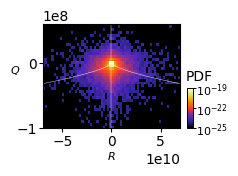

In [23]:
print(np.amax(val_R), np.amin(val_R))
print(np.amax(val_Q), np.amin(val_Q))
print(np.amax(pdf), np.amin(pdf))

fig_width = 18/2.54
fig_height = 18/2.54
fig = plt.figure(figsize=(fig_width, fig_height))

ax_width = 3.5/2.54 / fig_width
ax_height = ax_width / 4 * 3
cbar_length = 1/2.54 / fig_width
cbar_width = 1.2/8/2.54 / fig_width

# 
ax = fig.add_axes([0, 0, ax_width, ax_height])

R, Q = np.meshgrid(val_R, val_Q, indexing='ij')
ax.pcolormesh(R, Q, np.log10(pdf+1e-100), cmap='CMRmap', vmin=-25, vmax=-19, rasterized=True)
ax.axvline(x=0, linewidth=0.3, color='white')
# ax.axhline(y=0, linewidth=0.25, color='white')
R0 = np.linspace(np.amin(R), np.amax(R), 3000)
ax.plot(R0, -3*(R0**2/4)**(1/3), linewidth=0.3, color='white')

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useOffset=False)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
ax.yaxis.set_major_formatter(formatter)

plt.xlim(-7e10, 7e10) 
plt.ylim(-1e8, 6e7)
plt.xlabel(r'$R$', labelpad=1, size=8)
plt.ylabel(r'$Q$', labelpad=1, size=8, rotation=0) # rotation=0
# ax.set_xticks(np.linspace(-2e8, 2e8, 5))
# ax.set_yticks(np.linspace(-1.6e6, 1.6e6, 3))
ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, pad=1.5)
ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, pad=1)
ax.tick_params(which='minor', direction='out', top=False, right=False, length=1.5)

cax = fig.add_axes([ax_width+0.01, 0, cbar_width, cbar_length])
cbar = plt.colorbar(mpl.cm.ScalarMappable(mpl.colors.Normalize(vmin=0, vmax=1), 'CMRmap'), ax=ax, cax=cax, orientation='vertical', ticks=[0, 0.5, 1], location='right')
cbar.set_ticklabels(['$10^{-25}$', '$10^{-22}$', '$10^{-19}$'])
cax.text(2, 1.3, 'PDF', ha='center', va='center')
cbar.ax.tick_params(length=2, width=0.7, labelsize=8, pad=0)
cbar.outline.set_linewidth(0.7)


# 
# plt.savefig(fr'figures/RQ.pdf', transparent=True, orientation='portrait', format='pdf', bbox_inches='tight', dpi=600)

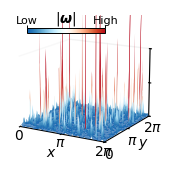

In [37]:
fig_width = 15/2.54
fig_height = 15/2.54

fig = plt.figure(figsize=(fig_width, fig_height))

ax_width = 5/2.54 / fig_width
ax_height = ax_width / 4 * 3
cbar_length = 2/2.54 / fig_width
cbar_width = 1/8/2.54 / fig_width

ax = fig.add_axes([0, 0, ax_width, ax_height], projection='3d')

X, Y = np.meshgrid(np.linspace(0, 2*np.pi, N), np.linspace(0, 2*np.pi, N), indexing='ij')
from mpl_toolkits.mplot3d import axes3d 
from matplotlib import cm
ax.plot_surface(X, Y, vor[:, :, 0], rstride=2, cstride=2, alpha=1, cmap=cmap_BuRd, vmin=0, vmax=2000, rasterized=True)
ax.view_init(elev=15, azim=-60)

ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.zaxis.set_visible(False)

ax.set_xlim(0, 2*np.pi)
ax.set_ylim(0, 2*np.pi)
ax.set_zlim(0, 4000)
ax.set_xlabel(r'$x$', labelpad=-11)
ax.set_ylabel(r'$y$', labelpad=-11)
# ax.set_zlabel(r'$|\boldsymbol{\omega}|$', labelpad=-7)
ax.set_xticks(np.linspace(0, 2*np.pi, 3))
ax.set_xticklabels(['$0$', r'$\pi$', r'$2\pi$'])
ax.set_yticks(np.linspace(0, 2*np.pi, 3))
ax.set_yticklabels(['$0$', r'$\pi$', r'$2\pi$'])
ax.set_zticklabels([])
ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, pad=-7)
ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, pad=-5)
ax.tick_params(axis='z', which='major', direction='out', top=False, right=False, length=0, pad=0)

cax = fig.add_axes([0.07, ax_height-0.03, cbar_length, cbar_width])
cbar = plt.colorbar(mpl.cm.ScalarMappable(mpl.colors.Normalize(vmin=0, vmax=1), cmap_BuRd), ax=ax, cax=cax, orientation='horizontal', ticks=[0, 1], location='top')
cbar.set_ticklabels(['Low', 'High'])
cax.text(0.5, 3, r"$|\boldsymbol{\omega}|$", ha='center', va='center')
cbar.ax.tick_params(length=2, width=0.7, labelsize=8, pad=0)
cbar.outline.set_linewidth(0.7)

# 
# plt.savefig(fr'figures/test.pdf', transparent=True, orientation='portrait', format='pdf', bbox_inches='tight', dpi=600) # bbox_inches='tight'

In [ ]:
def calculate_structure_function(ux, uy, uz, p, n_samples=1_000_000, n_bins=50):
    Nx, Ny, Nz = ux.shape

    i1 = np.random.randint(0, Nx, size=n_samples)
    j1 = np.random.randint(0, Ny, size=n_samples)
    k1 = np.random.randint(0, Nz, size=n_samples)
    i2 = np.random.randint(0, Nx, size=n_samples)
    j2 = np.random.randint(0, Ny, size=n_samples)
    k2 = np.random.randint(0, Nz, size=n_samples)

    dr_x = i2.astype(float) - i1.astype(float)
    dr_y = j2.astype(float) - j1.astype(float)
    dr_z = k2.astype(float) - k1.astype(float)
    r = np.sqrt(dr_x**2 + dr_y**2 + dr_z**2)
    
    valid_mask = r > 0
    if not np.any(valid_mask):
        print("Error")
        return np.array([]).reshape(-1, 1), np.array([]).reshape(-1, 1)
        
    r = r[valid_mask]
    dr_x, dr_y, dr_z = dr_x[valid_mask], dr_y[valid_mask], dr_z[valid_mask]
    i1, j1, k1 = i1[valid_mask], j1[valid_mask], k1[valid_mask]
    i2, j2, k2 = i2[valid_mask], j2[valid_mask], k2[valid_mask]

    u1 = np.array([ux[i1, j1, k1], uy[i1, j1, k1], uz[i1, j1, k1]])
    u2 = np.array([ux[i2, j2, k2], uy[i2, j2, k2], uz[i2, j2, k2]])
    du = u2 - u1

    du_long = np.einsum('ij,ij->j', du, np.array([dr_x, dr_y, dr_z])) / r
    sp_values = np.abs(du_long)**p

    max_r = np.sqrt(Nx**2 + Ny**2 + Nz**2)
    r_bins = np.logspace(np.log10(1.0), np.log10(max_r), n_bins + 1)
    r_centers = 0.5 * (r_bins[:-1] + r_bins[1:])

    bin_indices = np.digitize(r, r_bins) - 1

    valid_bin_mask = (bin_indices >= 0) & (bin_indices < n_bins)
    
    bin_sums = np.bincount(
        bin_indices[valid_bin_mask],
        weights=sp_values[valid_bin_mask],
        minlength=n_bins
    )
    bin_counts = np.bincount(
        bin_indices[valid_bin_mask],
        minlength=n_bins
    )

    Sp = np.zeros_like(r_centers)
    non_zero_counts = bin_counts > 0
    Sp[non_zero_counts] = bin_sums[non_zero_counts] / bin_counts[non_zero_counts]

    # from scipy.interpolate import UnivariateSpline
    # x = np.log(r_centers.reshape(-1))
    # y = np.log(Sp.reshape(-1))
    # spline = UnivariateSpline(x, y, s=5*p**2)
    # ys = spline(x) 
    # r_s = np.exp(x)
    # sp_s = np.exp(ys)

    return r_centers.reshape(-1), Sp.reshape(-1)

r, s2 = calculate_structure_function(ux, uy, uz, 2, n_samples=10_000_000_000, n_bins=50)
r, s3 = calculate_structure_function(ux, uy, uz, 3, n_samples=10_000_000_000, n_bins=50)
r, s4 = calculate_structure_function(ux, uy, uz, 4, n_samples=10_000_000_000, n_bins=50)
r, s5 = calculate_structure_function(ux, uy, uz, 5, n_samples=10_000_000_000, n_bins=50)

In [24]:
import pandas as pd

header_names = [
    'r', 
    's2', 
    's3', 
    's4', 
    's5',
    # 's6', 
    # 's7', 
    # 's8'
]

r = r.reshape(-1)
s2 = s2.reshape(-1)
s3 = s3.reshape(-1)
s4 = s4.reshape(-1)
s5 = s5.reshape(-1)
# s6 = s6.reshape(-1)
# s7 = s7.reshape(-1)
# s8 = s8.reshape(-1)

data_dict = dict(zip(header_names, [r, s2, s3, s4, s5]))
df = pd.DataFrame(data_dict)
output_filename = fr'data/3D/structure_functions.csv'
df.to_csv(output_filename, index=False)

In [ ]:
import pyvista as pv

psi1_plot = np.abs(np.fft.fftshift(psi1_spec))**2
psi1_plot = psi1_plot / np.amax(psi1_plot)

grid = pv.ImageData()
dims = (N, N, N)
grid.dimensions = dims
grid.spacing = (1, 1, 1)

grid['amplitude'] = psi1_plot.flatten(order='F')

plotter = pv.Plotter(notebook=False, off_screen=False)   # output to file: off_screen=True)

vol = plotter.add_volume(
    grid,
    scalar_bar_args={'title': 'Amplitude'},
    cmap='Blues',
    clim=[1e-6, 0.8],
    log_scale=True,
    # opacity='sigmoid',
    show_scalar_bar=False
)

# plotter.enable_anti_aliasing() 
light = pv.Light()
light.intensity = 0.5      
light.positional = True       
light.position = (6, 9, 9)     
# light.show_actor()        
plotter.add_light(light)

plotter.camera.azimuth = 70
plotter.camera.elevation = -15
plotter.disable_parallel_projection()   

plotter.show(screenshot=fr'figures/psi1_vol.png', window_size=[3000, 3000])

In [ ]:
import pyvista as pv

rho_plot = np.abs(np.fft.fftshift(np.fft.fftn(rho)))**2
rho_plot = rho_plot / np.unique(rho_plot)[-2]

# ux_plot = np.abs(np.fft.fftshift(np.fft.fftn(ux)) / N**3)**2

grid = pv.ImageData()
dims = (N, N, N)
grid.dimensions = dims
grid.spacing = (1, 1, 1)

grid['amplitude'] = rho_plot.flatten(order='F')

plotter = pv.Plotter(notebook=False, off_screen=False)   # output to file: off_screen=True)

vol = plotter.add_volume(
    grid,
    scalar_bar_args={'title': 'Amplitude'},
    cmap='Blues',
    clim=[1e-6, 0.3],
    log_scale=True,
    # opacity='sigmoid',
    show_scalar_bar=False
)

# plotter.enable_anti_aliasing()  
light = pv.Light()
light.intensity = 0.5  
light.positional = True        
light.position = (6, 9, 9)
# light.show_actor()          
plotter.add_light(light)

plotter.camera.azimuth = 70
plotter.camera.elevation = -15
plotter.disable_parallel_projection() 

plotter.show(screenshot=fr'figures/psi1_vol.png', window_size=[3000, 3000])

In [ ]:
import pyvista as pv

ux_plot = np.abs(np.fft.fftshift(np.fft.fftn(ux)) / N**3)**2
ux_plot = ux_plot / np.unique(ux_plot)[-1]

grid = pv.ImageData()
dims = (N, N, N)
grid.dimensions = dims
grid.spacing = (1, 1, 1)

grid['amplitude'] = ux_plot.flatten(order='F')

plotter = pv.Plotter(notebook=False, off_screen=False)   # output to file: off_screen=True)

vol = plotter.add_volume(
    grid,
    scalar_bar_args={'title': 'Amplitude'},
    cmap='Blues',
    clim=[1e-6, 0.1],
    log_scale=True,
    # opacity='sigmoid',
    show_scalar_bar=False
)

# plotter.enable_anti_aliasing() 
light = pv.Light()
light.intensity = 0.5      
light.positional = True       
light.position = (6, 9, 9) 
# light.show_actor()           
plotter.add_light(light)

plotter.camera.azimuth = 70
plotter.camera.elevation = -15
plotter.disable_parallel_projection() 

plotter.show(screenshot=fr'figures/psi1_vol.png', window_size=[3000, 3000])

Volumn rendering of vorticity field

In [ ]:
import pyvista as pv

grid = pv.ImageData()
dims = (N, N, N)
grid.dimensions = dims
grid.spacing = (1, 1, 1)

grid['amplitude'] = vor.flatten(order='F')

plotter = pv.Plotter(notebook=False, off_screen=True)   # output to file: off_screen=True)

vol = plotter.add_volume(
    grid,
    scalar_bar_args={'title': 'Amplitude'},
    cmap='Blues',
    clim=[0, 500],
    # log_scale=True,
    # opacity='sigmoid',
    show_scalar_bar=False,
)

bounds = vol.bounds

def add_background_plane(plotter, position, normal, size, color='black'):
    plane = pv.Plane(center=position, direction=normal, i_size=size[0], j_size=size[1])
    plotter.add_mesh(plane, color=color, opacity=1)

background_planes = [
    {
        'position': (N, (bounds[2] + bounds[3]) / 2, (bounds[4] + bounds[5]) / 2), 
        'normal': (-1, 0, 0), 
        'size': ((bounds[1] - bounds[0]), (bounds[3] - bounds[2]), (bounds[5] - bounds[4]))
    },
    {
        'position': ((bounds[0] + bounds[1]) / 2, 0, (bounds[4] + bounds[5]) / 2), 
        'normal': (0, -1, 0), 
        'size': ((bounds[1] - bounds[0]), (bounds[3] - bounds[2]), (bounds[5] - bounds[4]))
    },
    {
        'position': ((bounds[0] + bounds[1]) / 2, (bounds[2] + bounds[3]) / 2, 0), 
        'normal': (0, 0, -1), 
        'size': ((bounds[1] - bounds[0]), (bounds[3] - bounds[2]), 0)
    }
]

for plane in background_planes:
    add_background_plane(plotter, **plane)

plotter.add_mesh(grid.outline(), color='grey', line_width=5)

# plotter.enable_anti_aliasing()  
light = pv.Light()
light.intensity = 0.5       
light.positional = True        
light.position = (6, 9, 9)   
# light.show_actor()          
plotter.add_light(light)

plotter.camera.azimuth = 70
plotter.camera.elevation = -15
plotter.disable_parallel_projection()  

plotter.show(screenshot=fr'figures/vor_volume_render_nq=27.png', window_size=[3000, 3000])

Volume render of $\rho$

In [ ]:
import pyvista as pv

grid = pv.ImageData()
dims = (N, N, N)
grid.dimensions = dims
grid.spacing = (1, 1, 1)

grid['amplitude'] = rho.flatten(order='F')

plotter = pv.Plotter(notebook=False, off_screen=True)   # output to file: off_screen=True)

vol = plotter.add_volume(
    grid,
    scalar_bar_args={'title': 'Amplitude'},
    cmap='Reds',
    clim=[0, 1e-16],
    # log_scale=True,
    opacity='sigmoid',
    show_scalar_bar=False,
)

bounds = vol.bounds

def add_background_plane(plotter, position, normal, size, color='black'):
    plane = pv.Plane(center=position, direction=normal, i_size=size[0], j_size=size[1])
    plotter.add_mesh(plane, color=color, opacity=1)

background_planes = [
    {
        'position': (N, (bounds[2] + bounds[3]) / 2, (bounds[4] + bounds[5]) / 2), 
        'normal': (-1, 0, 0), 
        'size': ((bounds[1] - bounds[0]), (bounds[3] - bounds[2]), (bounds[5] - bounds[4]))
    },
    {
        'position': ((bounds[0] + bounds[1]) / 2, 0, (bounds[4] + bounds[5]) / 2), 
        'normal': (0, -1, 0), 
        'size': ((bounds[1] - bounds[0]), (bounds[3] - bounds[2]), (bounds[5] - bounds[4]))
    },
    {
        'position': ((bounds[0] + bounds[1]) / 2, (bounds[2] + bounds[3]) / 2, 0), 
        'normal': (0, 0, -1), 
        'size': ((bounds[1] - bounds[0]), (bounds[3] - bounds[2]), 0)
    }
]

for plane in background_planes:
    add_background_plane(plotter, **plane)

plotter.add_mesh(grid.outline(), color='grey', line_width=5)

# plotter.enable_anti_aliasing()  
light = pv.Light()
light.intensity = 0.5     
light.positional = True    
light.position = (6, 9, 9)    
# light.show_actor()       
plotter.add_light(light)

plotter.camera.azimuth = 70
plotter.camera.elevation = -15
plotter.disable_parallel_projection()    

plotter.show(screenshot=fr'figures/rho_volume_render_nq=27.png', window_size=[3000, 3000])

In [3]:
def calculate_anisotropy_tensor(ux, uy, uz):
    ux_prime = ux - np.mean(ux)
    uy_prime = uy - np.mean(uy)
    uz_prime = uz - np.mean(uz)

    two_K = np.mean(ux_prime**2 + uy_prime**2 + uz_prime**2)

    if two_K == 0:
        return {"b11": 0.0, "b22": 0.0, "b33": 0.0, 
                "b12": 0.0, "b13": 0.0, "b23": 0.0}

    R11 = np.mean(ux_prime * ux_prime)
    R22 = np.mean(uy_prime * uy_prime)
    R33 = np.mean(uz_prime * uz_prime)
    R12 = np.mean(ux_prime * uy_prime)
    R13 = np.mean(ux_prime * uz_prime)
    R23 = np.mean(uy_prime * uz_prime)

    b11 = R11 / two_K - 1.0 / 3.0
    b22 = R22 / two_K - 1.0 / 3.0
    b33 = R33 / two_K - 1.0 / 3.0

    b12 = R12 / two_K
    b13 = R13 / two_K
    b23 = R23 / two_K

    b_components = {
        "b11": b11,
        "b22": b22,
        "b33": b33,
        "b12": b12,
        "b13": b13,
        "b23": b23
    }
    
    return b_components

anisotropy_components = calculate_anisotropy_tensor(ux, uy, uz)

for component, value in anisotropy_components.items():
    print(f"{component}: {value:.6f}")

b11: -0.001334
b22: -0.001983
b33: 0.003318
b12: 0.004853
b13: 0.003047
b23: 0.009083


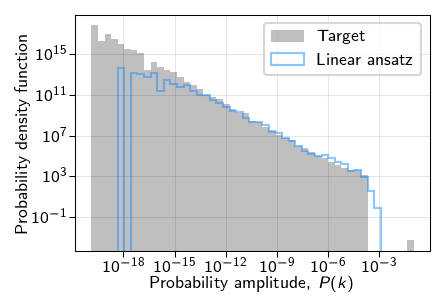

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

t_vals = target_probs_phys.flatten()
s_vals = amp_sim_phys.flatten()**2

mask = t_vals > 1e-20
t_vals = t_vals[mask]
s_vals = s_vals[mask] 

fig_width = 18/2.54
fig_height = 18/2.54
fig = plt.figure(figsize=(fig_width, fig_height))

ax_width = 6/2.54 / fig_width
ax_height = 4/2.54 / fig_height

# 
ax = fig.add_axes([0, 0, ax_width, ax_height])
ax.grid(color='k', linestyle='-', linewidth=0.5, alpha=0.1)
bins = np.logspace(np.log10(min(t_vals)), np.log10(max(t_vals)), 50)

plt.hist(t_vals, bins=bins, alpha=0.5, color='gray', label='Target', density=True, log=True)
plt.hist(s_vals, bins=bins, alpha=0.5, color='dodgerblue', histtype='step', linewidth=1, label='Linear ansatz', density=True, log=True)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1.5)
ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1)
ax.tick_params(which='minor', direction='out', top=False, right=False, length=1.5, width=0.5)
plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'Probability amplitude, $P(k)$', labelpad=0, fontsize=fontsize)
plt.ylabel(r'Probability density function', labelpad=1, fontsize=fontsize)
plt.legend()

# plt.savefig(fr'figures/pdf_Pk.pdf', transparent=True, orientation='portrait', format='pdf', bbox_inches='tight')